# Testing the 2D KS test as implemented in the ndtest package

I'm a bit concerned about the generality of this method (at least computationally)

In [1]:
import ndtest
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Case 0: reproducing the example in the repo

P=0.126, D=0.19
P=9.48e-05, D=0.36


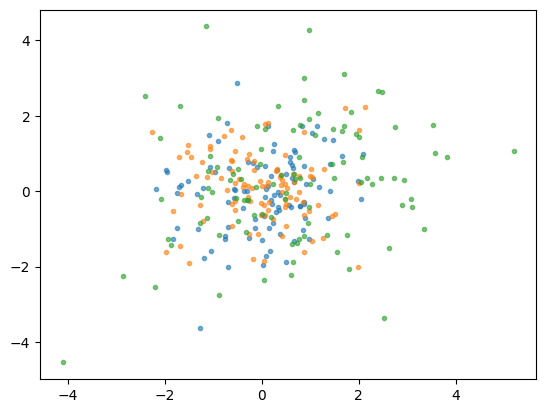

In [2]:
# Generate 2 × 100 independent standard normal samples. x1 and y1 are independent.
x1, y1 = np.random.randn(2, 100)
x2, y2 = np.random.randn(2, 100)  # same distribution as (x1, y1)
x3, y3 = np.random.randn(2, 100) * 1.5 + 0.5  # different distribution from (x1, y1)

plt.plot(x1,y1,'.',alpha=0.6,label='sample 1')
plt.plot(x2,y2,'.',alpha=0.6,label='sample 2')
plt.plot(x3,y3,'.',alpha=0.6,label='sample 3')


# 2D KS
P, D = ndtest.ks2d2s(x1, y1, x2, y2, extra=True)
print(f"{P=:.3g}, {D=:.3g}")

P, D = ndtest.ks2d2s(x1, y1, x3, y3, extra=True)
print(f"{P=:.3g}, {D=:.3g}")

So far so good.

## Case 0 - extension: same test with higher number of points

Running a few times just to check

In [3]:
P12_list = []
P13_list = []

for i in tqdm(range(1000)):
    x1, y1 = np.random.randn(2, 1000)
    x2, y2 = np.random.randn(2, 1000)  # same distribution as (x1, y1)
    x3, y3 = np.random.randn(2, 1000) * 1.5 + 0.5  # different distribution from (x1, y1)

    # 2D KS
    P12, D12 = ndtest.ks2d2s(x1, y1, x2, y2, extra=True)
    #print(f"1 & 2: {P=:.3g}, {D=:.3g}")

    P13, D13 = ndtest.ks2d2s(x1, y1, x3, y3, extra=True)
    #print(f"1 & 3: {P=:.3g}, {D=:.3g}")
    P12_list.append(P12)
    P13_list.append(P13)

100%|██████████| 1000/1000 [02:03<00:00,  8.12it/s]


Text(0, 0.5, '#occurrence per bin')

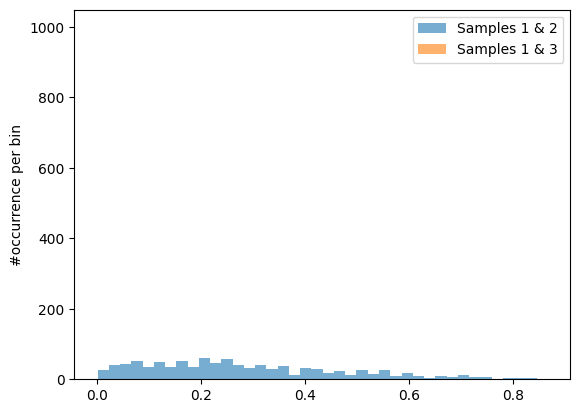

In [4]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.hist(P13_list,bins=40,alpha=0.6,label='Samples 1 & 3')
plt.legend()
#plt.xlabel('log(p)')
plt.ylabel('#occurrence per bin')

In [5]:
max(P13_list)

np.float64(2.0084852200252277e-20)

So far so good! Note that the 1 & 2 p-values should appear relatively uniformly distributed between 0 and 1 (p-value has a uniform distribution under the assumption that the null hypothesis is true) and 1 & 3 should be always low, which is the case, so this is good.

## Case 0 - in scipy

I prefer Scipy's stats distributions, so retrying case 0 with that

100%|██████████| 1000/1000 [02:30<00:00,  6.64it/s]


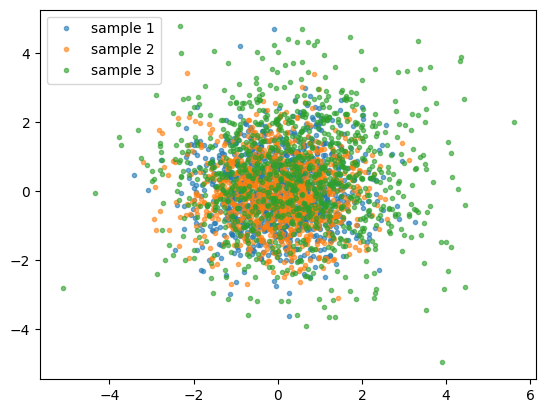

In [7]:
P12_list = []
P13_list = []

for i in tqdm(range(1000)):
    # Sample 1
    # Should be the same as the way we sampled before as we use unit variance
    samp1 = st.multivariate_normal([0,0],
                                   [[1,0],
                                    [0,1]]
                                  ).rvs(1000)
    # sample 2: identical to sample 1
    samp2 = st.multivariate_normal([0,0],
                                   [[1,0],
                                    [0,1]]
                                  ).rvs(1000)

    # Sample 3: different than sample 1
    # 1.5**2 = 2.25
    samp3 = st.multivariate_normal([0.5,0.5],
                                   [[2.25,0],
                                    [0,2.25]]
                                  ).rvs(1000)

    if i == 0:
        plt.plot(samp1.T[0],samp1.T[1],'.',alpha=0.6,label='sample 1')
        plt.plot(samp2.T[0],samp2.T[1],'.',alpha=0.6,label='sample 2')
        plt.plot(samp3.T[0],samp3.T[1],'.',alpha=0.6,label='sample 3')
        plt.legend()

    P12 = ndtest.ks2d2s(x1=samp1.T[0], y1=samp1.T[1], x2=samp2.T[0], y2=samp2.T[1])
    P13 = ndtest.ks2d2s(x1=samp1.T[0], y1=samp1.T[1], x2=samp3.T[0], y2=samp3.T[1])
    P12_list.append(P12)
    P13_list.append(P13)


Text(0, 0.5, '#occurrence per bin')

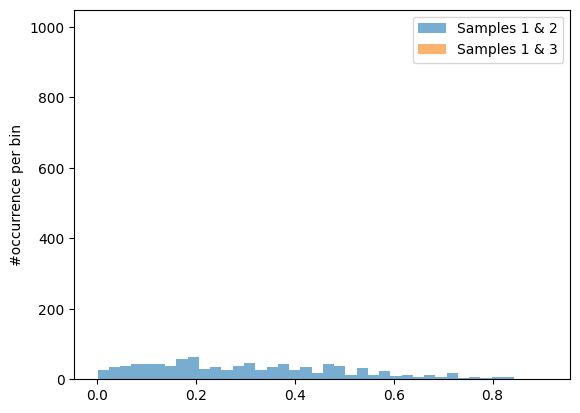

In [8]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.hist(P13_list,bins=40,alpha=0.6,label='Samples 1 & 3')
plt.legend()
#plt.xlabel('log(p)')
plt.ylabel('#occurrence per bin')

In [9]:
max(P13_list)

np.float64(4.800170423780727e-21)

## Case 1: uniform distributions with slight edge differences

100%|██████████| 1000/1000 [02:29<00:00,  6.67it/s]


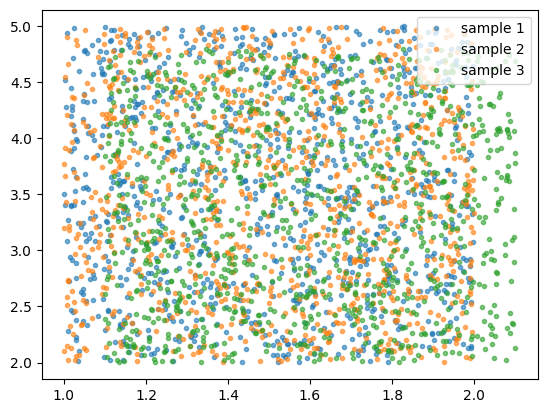

In [10]:
P12_list = []
P13_list = []

for i in tqdm(range(1000)):
    # Sample 1
    samp1 = st.uniform(loc=[1,2],scale=[1,3]).rvs([1000,2])

    # Sample 2: identical to sample 1
    samp2 = st.uniform(loc=[1,2],scale=[1,3]).rvs([1000,2])

    # Sample 3: different than sample 1
    samp3 = st.uniform(loc=[1.1,2],scale=[1,2.8]).rvs([1000,2])

    if i == 0:
        plt.plot(samp1.T[0],samp1.T[1],'.',alpha=0.6,label='sample 1')
        plt.plot(samp2.T[0],samp2.T[1],'.',alpha=0.6,label='sample 2')
        plt.plot(samp3.T[0],samp3.T[1],'.',alpha=0.6,label='sample 3')
        plt.legend()

    P12 = ndtest.ks2d2s(x1=samp1.T[0], y1=samp1.T[1], x2=samp2.T[0], y2=samp2.T[1])
    P13 = ndtest.ks2d2s(x1=samp1.T[0], y1=samp1.T[1], x2=samp3.T[0], y2=samp3.T[1])
    P12_list.append(P12)
    P13_list.append(P13)


In [11]:
print(max(P12_list))
print(max(P13_list))

0.9015101282162231
6.142318106907809e-05


Text(0, 0.5, '#occurrence per bin')

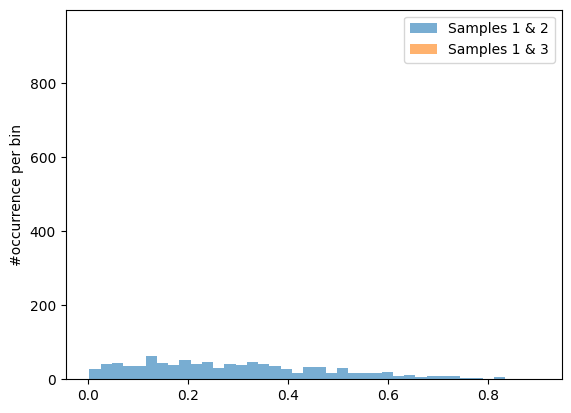

In [12]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.hist(P13_list,bins=40,alpha=0.6,label='Samples 1 & 3')
plt.legend()
#plt.xlabel('log(p)')
plt.ylabel('#occurrence per bin')

## Case 2: correlated bi-variate gaussian distributions with slight mean shifts

100%|██████████| 1000/1000 [02:45<00:00,  6.04it/s]


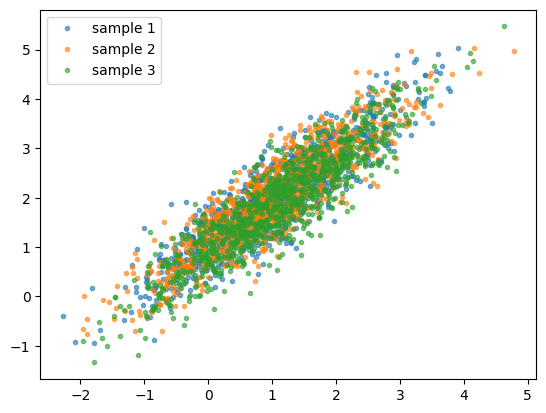

In [13]:
P12_list = []
P13_list = []

for i in tqdm(range(1000)):
    # Sample 1
    samp1 = st.multivariate_normal([1,2],
                                   [[1,0.9],
                                    [0.9,1]]
                                  ).rvs(1000)
    # sample 2: identical to sample 1
    samp2 = st.multivariate_normal([1,2],
                                   [[1,0.9],
                                    [0.9,1]]
                                  ).rvs(1000)

    # Sample 3: different than sample 1
    samp3 = st.multivariate_normal([1.1,1.9],
                                   [[1,0.9],
                                    [0.9,1]]
                                  ).rvs(1000)

    if i == 0:
        plt.plot(samp1.T[0],samp1.T[1],'.',alpha=0.6,label='sample 1')
        plt.plot(samp2.T[0],samp2.T[1],'.',alpha=0.6,label='sample 2')
        plt.plot(samp3.T[0],samp3.T[1],'.',alpha=0.6,label='sample 3')
        plt.legend()

    P12 = ndtest.ks2d2s(x1=samp1.T[0], y1=samp1.T[1], x2=samp2.T[0], y2=samp2.T[1])
    P13 = ndtest.ks2d2s(x1=samp1.T[0], y1=samp1.T[1], x2=samp3.T[0], y2=samp3.T[1])
    P12_list.append(P12)
    P13_list.append(P13)


Text(0, 0.5, '#occurrence per bin')

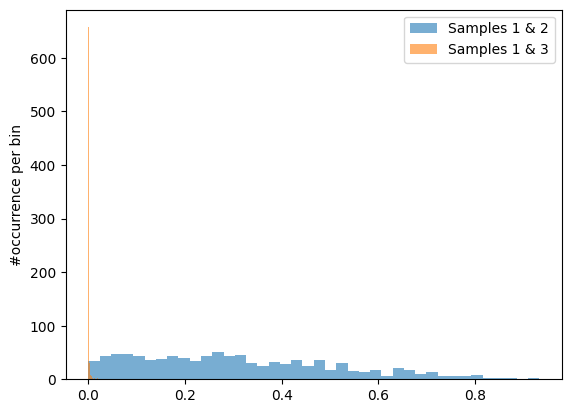

In [15]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.hist(P13_list,bins=40,alpha=0.6,label='Samples 1 & 3')
plt.legend()
#plt.xlabel('log(p)')
plt.ylabel('#occurrence per bin')

Text(0, 0.5, '#occurrence per bin')

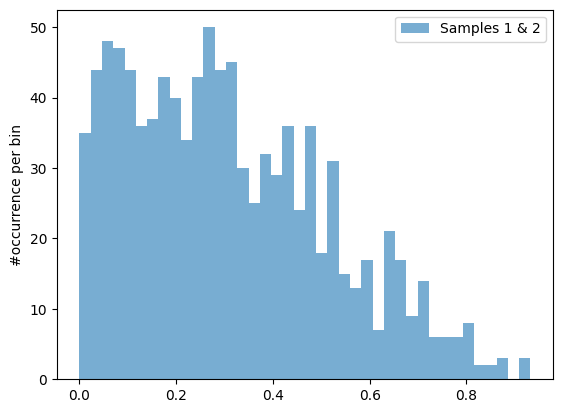

In [16]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.legend()
plt.ylabel('#occurrence per bin')

Note that the distribution is not quite uniform between zero and one. 

Text(0, 0.5, '#occurrence per bin')

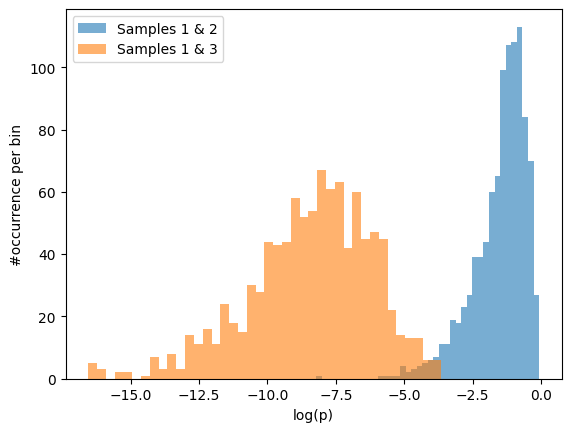

In [14]:
plt.hist(np.log(P12_list),bins=40,alpha=0.6,label='Samples 1 & 2')
plt.hist(np.log(P13_list),bins=40,alpha=0.6,label='Samples 1 & 3')
plt.legend()
plt.xlabel('log(p)')
plt.ylabel('#occurrence per bin')

So the method/package is not ideal, but can be used with caveats. 

---

# Comparison of 1D KS test

In [17]:
from scipy import stats

n_reps = 1000
n_sample = 1000

P12_list = []
P13_list = []

for i in tqdm(range(n_reps), desc="reps"):
    # Sample 1 & 2: identical distribution N(0, 1)
    x1 = np.random.randn(n_sample)
    x2 = np.random.randn(n_sample)
    # Sample 3: different distribution N(0.5, 1.5) -> std = sqrt(1.5)
    x3 = np.random.randn(n_sample) * np.sqrt(1.5) + 0.5

    # 1D two-sample KS test (returns statistic, pvalue)
    D12, P12 = stats.ks_2samp(x1, x2, alternative='two-sided', mode='asymp')
    D13, P13 = stats.ks_2samp(x1, x3, alternative='two-sided', mode='asymp')

    P12_list.append(P12)
    P13_list.append(P13)

reps: 100%|██████████| 1000/1000 [00:01<00:00, 768.87it/s]


Text(0, 0.5, '#occurrence per bin')

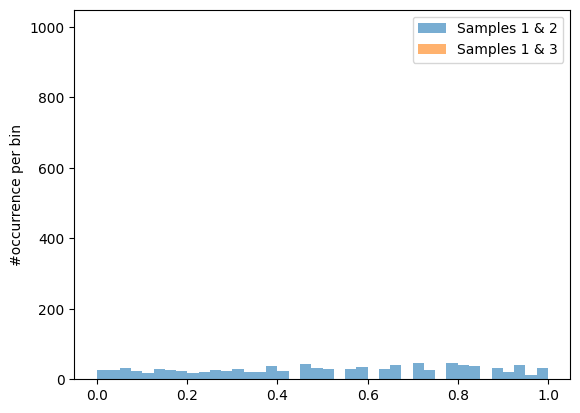

In [18]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.hist(P13_list,bins=40,alpha=0.6,label='Samples 1 & 3')
plt.legend()
#plt.xlabel('log(p)')
plt.ylabel('#occurrence per bin')

In [21]:
np.max(P13_list)

np.float64(9.088525907097205e-09)

Text(0, 0.5, '#occurrence per bin')

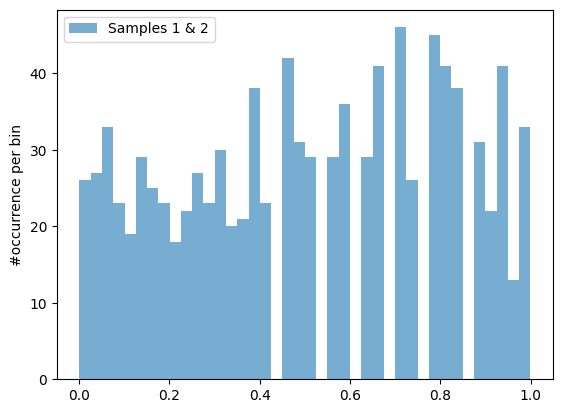

In [19]:
plt.hist(P12_list,bins=40,alpha=0.6,label='Samples 1 & 2')
plt.legend()
plt.ylabel('#occurrence per bin')